<a href="https://colab.research.google.com/github/AliefReefandi/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_7_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 — Unsupervised Learning

Chapter ini membahas **Unsupervised Learning**, yaitu metode pembelajaran mesin yang digunakan untuk menemukan pola atau struktur dalam data tanpa menggunakan variabel target.

Materi utama dalam chapter ini meliputi:

- Principal Components Analysis (PCA)
- K-Means Clustering
- Hierarchical Clustering
- Model-Based Clustering
- Scaling dan Categorical Variables

## 1. Tujuan Pembelajaran

Setelah mempelajari chapter ini, diharapkan dapat:

- Memahami konsep Unsupervised Learning.
- Memahami Principal Components Analysis (PCA).
- Memahami konsep dan cara kerja K-Means Clustering.
- Memahami Hierarchical Clustering dan dendrogram.
- Memahami konsep Model-Based Clustering.
- Memahami pentingnya scaling dalam proses clustering.
- Memahami pengaruh categorical variables terhadap clustering.
- Menentukan jumlah cluster berdasarkan hasil analisis.


## 2. Ringkasan Chapter

Unsupervised Learning digunakan ketika data tidak memiliki variabel target yang ingin diprediksi. Tujuannya adalah menemukan struktur, pola, atau kelompok yang terdapat di dalam data.

Chapter ini membahas beberapa metode utama, yaitu:

1. **Principal Components Analysis (PCA)**  
   Digunakan untuk mengurangi dimensi data dengan mempertahankan informasi penting.

2. **K-Means Clustering**  
   Digunakan untuk membagi data menjadi beberapa kelompok berdasarkan kemiripan.

3. **Hierarchical Clustering**  
   Membentuk struktur kelompok secara bertahap dan dapat ditampilkan menggunakan dendrogram.

4. **Model-Based Clustering**  
   Menggunakan pendekatan statistik untuk menentukan struktur cluster.

Selain metode clustering, chapter ini juga membahas pentingnya scaling data, terutama ketika variabel memiliki skala yang berbeda.

## 3.1 Principal Components Analysis (PCA)

**Principal Components Analysis (PCA)** merupakan metode yang digunakan untuk mengurangi jumlah variabel dalam dataset.

PCA mengubah beberapa variabel asli menjadi beberapa **principal components** yang dapat mewakili sebagian besar variasi dalam data.

Principal component pertama menangkap variasi terbesar dalam data. Component berikutnya menangkap variasi yang masih tersisa.

### Tujuan PCA

PCA dapat digunakan untuk:

- Mengurangi dimensi data.
- Mempermudah visualisasi data.
- Mengurangi jumlah variabel yang digunakan dalam analisis.
- Menghilangkan sebagian redundansi antarvariabel.

Salah satu hal yang perlu diperhatikan adalah interpretasi principal components dapat menjadi lebih sulit karena setiap component merupakan kombinasi dari beberapa variabel.

## 3.2 K-Means Clustering

**K-Means Clustering** merupakan metode untuk membagi data menjadi beberapa kelompok atau **cluster** berdasarkan kemiripan antar-record.

Beberapa istilah penting:

- **Cluster** → kelompok record yang memiliki karakteristik serupa.
- **Cluster mean** → rata-rata variabel dari record dalam suatu cluster.
- **K** → jumlah cluster yang ingin dibuat.

K-Means membagi data menjadi K cluster dengan meminimalkan jumlah kuadrat jarak setiap record terhadap rata-rata cluster-nya.

Nilai ini disebut **within-cluster sum of squares**.

### Cara Kerja K-Means

Secara umum, algoritma K-Means bekerja dengan langkah:

1. Menentukan jumlah cluster K.
2. Menentukan pusat awal cluster.
3. Menempatkan setiap record ke cluster dengan pusat terdekat.
4. Menghitung kembali pusat masing-masing cluster.
5. Mengulangi proses sampai pembagian cluster tidak berubah.

In [2]:
import pandas as pd

sp500_px = pd.read_csv(
    'sp500_data.csv.gz',
    index_col=0,
    parse_dates=True
)

sp500_px.head()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
1993-01-29,0.0,0.060124,-0.022100,0.0,0.0,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.0,0.0,0.34716,0.0,0.04167,0.00000,0.015564,1.75,0.1250,0.0
1993-02-01,0.0,-0.180389,0.027621,0.0,0.0,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.0,0.0,-0.23144,0.0,0.00000,-0.01041,0.007782,1.25,0.1250,0.0
1993-02-02,0.0,-0.120257,0.035900,0.0,0.0,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.0,0.0,-0.11572,0.0,0.00000,0.00000,-0.007792,-0.25,0.0000,0.0
1993-02-03,0.0,0.060124,-0.024857,0.0,0.0,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.0,0.0,-0.08679,0.0,0.04167,-0.04167,-0.038919,-0.50,0.0625,0.0
1993-02-04,0.0,-0.360770,-0.060757,0.0,0.0,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.0,0.0,0.14465,0.0,-0.04166,-0.03126,-0.046711,0.00,0.0625,0.0


In [3]:
from sklearn.cluster import KMeans
import pandas as pd

syms = sorted([
    'AAPL', 'MSFT', 'CSCO', 'INTC',
    'CVX', 'XOM', 'SLB', 'COP',
    'JPM', 'WFC', 'USB', 'AXP',
    'WMT', 'TGT', 'HD', 'COST'
])

top_sp = sp500_px.loc[
    sp500_px.index >= '2011-01-01',
    syms
]

kmeans = KMeans(
    n_clusters=5,
    random_state=0
).fit(top_sp)

print(kmeans.labels_)

[4 0 4 ... 3 1 0]


### Analisis

Kode di atas menerapkan K-Means dengan jumlah cluster sebanyak 5.

`kmeans.labels_` menunjukkan cluster yang diberikan kepada setiap record.

K-Means tidak hanya digunakan untuk menemukan kelompok yang secara alami terpisah, tetapi juga dapat digunakan untuk membagi data menjadi sejumlah kelompok tertentu.

In [4]:
from collections import Counter

Counter(kmeans.labels_)

Counter({np.int32(4): 343,
         np.int32(0): 245,
         np.int32(1): 284,
         np.int32(2): 145,
         np.int32(3): 114})

## 3.3 Standardization pada Clustering

Scaling atau standardization penting dalam proses clustering karena variabel dapat memiliki skala yang berbeda.

Contohnya:

- Pendapatan memiliki nilai jutaan.
- Usia memiliki nilai puluhan.

Jika data digunakan langsung, variabel dengan skala besar dapat memberikan pengaruh yang lebih besar terhadap perhitungan jarak.

Salah satu metode yang umum digunakan adalah **standardization atau z-score**.

Rumusnya:

$$
z = \frac{x-\bar{x}}{s}
$$

Keterangan:

- $x$ = nilai asli.
- $\bar{x}$ = rata-rata.
- $s$ = standar deviasi.

Dengan standardization, variabel dapat memiliki skala yang lebih sebanding.

## 3.4 Menentukan Jumlah Cluster

Salah satu masalah dalam K-Means adalah menentukan jumlah cluster atau nilai **K**.

Salah satu pendekatan yang dapat digunakan adalah membandingkan nilai **within-cluster sum of squares** untuk beberapa nilai K.

Grafik hasil perhitungan dapat digunakan untuk melihat pola penurunan nilai tersebut. Salah satu pendekatan yang sering digunakan adalah mencari titik yang menyerupai **elbow**.

Namun, tidak terdapat satu aturan yang selalu menentukan jumlah cluster yang paling tepat.

Cluster juga perlu diperhatikan berdasarkan:

- Apakah cluster dapat diinterpretasikan?
- Apakah cluster dapat direplikasi pada data baru?
- Apakah cluster sesuai dengan tujuan analisis?

In [6]:
inertia = []

for n_clusters in range(2, 14):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=0
    ).fit(top_sp)

    inertia.append(kmeans.inertia_ / n_clusters)

inertias = pd.DataFrame({
    'n_clusters': range(2, 14),
    'inertia': inertia
})

inertias

,n_clusters,inertia
0,2,3031.750886
1,3,1793.214413
2,4,1248.102435
3,5,945.719923
4,6,754.129358
5,7,624.259767
6,8,526.771429
7,9,455.168735
8,10,402.762315
9,11,357.553239


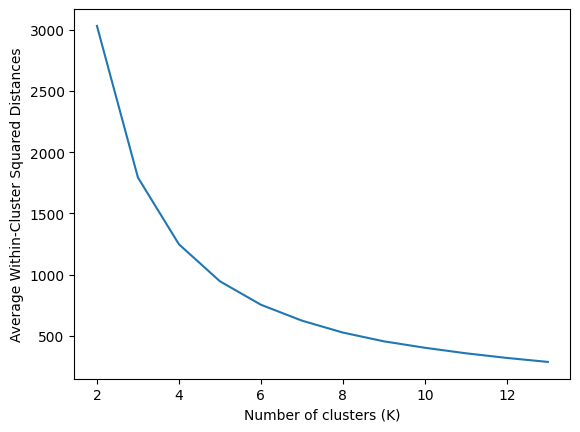

In [7]:
import matplotlib.pyplot as plt

ax = inertias.plot(
    x='n_clusters',
    y='inertia'
)

plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Within-Cluster Squared Distances')

ax.legend().set_visible(False)

plt.show()

## 3.5 Hierarchical Clustering

**Hierarchical Clustering** merupakan metode clustering alternatif dari K-Means.

Metode ini membangun struktur cluster secara bertahap. Hasilnya dapat ditampilkan dalam bentuk **dendrogram**.

### Istilah penting

- **Distance** → ukuran jarak antara dua record.
- **Dissimilarity** → ukuran perbedaan antara dua cluster.
- **Dendrogram** → visualisasi struktur hierarchical clustering.

Hierarchical clustering dimulai dengan setiap record sebagai cluster sendiri. Cluster yang paling dekat kemudian digabungkan secara bertahap sampai seluruh record menjadi satu cluster.

Salah satu kelebihan hierarchical clustering adalah pengguna dapat melihat struktur cluster pada berbagai jumlah cluster melalui dendrogram.

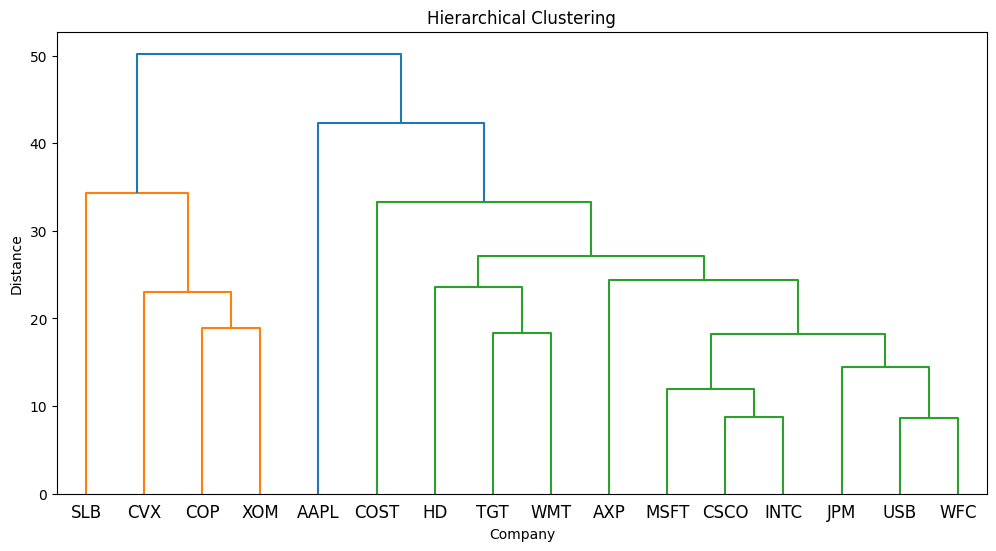

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Setiap perusahaan menjadi satu record
df = top_sp.T

# Membuat hierarchical clustering
linkage_matrix = linkage(
    df,
    method='ward'
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=df.index
)

plt.title('Hierarchical Clustering')
plt.xlabel('Company')
plt.ylabel('Distance')

plt.show()

### Analisis

Dendrogram menunjukkan bagaimana record atau perusahaan bergabung menjadi cluster.

Pada awal proses, setiap record dianggap sebagai cluster tersendiri. Selanjutnya, cluster yang memiliki jarak paling dekat akan digabungkan.

Dengan dendrogram, struktur pengelompokan dapat dilihat pada berbagai tingkat jumlah cluster.

Hierarchical clustering lebih fleksibel dalam melihat struktur cluster, tetapi membutuhkan sumber daya komputasi yang lebih besar dibandingkan K-Means pada dataset yang besar.

## 3.6 Model-Based Clustering

**Model-Based Clustering** menggunakan pendekatan berbasis model statistik untuk menemukan cluster.

Berbeda dengan K-Means dan hierarchical clustering yang terutama menggunakan pendekatan berbasis jarak atau heuristik, model-based clustering menggunakan model probabilistik.

Salah satu dasar yang digunakan adalah **multivariate normal distribution**.

Distribusi ini dijelaskan menggunakan:

- Vector mean.
- Covariance matrix.

Model-based clustering dapat memberikan pendekatan yang lebih berbasis teori statistik dalam menentukan struktur dan jumlah cluster.

Namun, metode ini juga memiliki asumsi dan perhitungan yang lebih kompleks.

## 3.7 Scaling dan Categorical Variables

K-Means dan PCA paling sesuai digunakan pada variabel numerik kontinu.

Ketika dataset memiliki categorical variables, diperlukan perhatian khusus.

Contoh categorical variable:

- `home = OWN`
- `home = RENT`
- `home = MORTGAGE`

Categorical variables dapat diubah menjadi representasi numerik menggunakan metode seperti one-hot encoding.

Namun, penggunaan K-Means pada binary atau categorical variables dapat menghasilkan cluster yang lebih banyak dipengaruhi oleh variabel tersebut.

Untuk dataset yang lebih kecil dengan data campuran numerik dan categorical, buku membahas penggunaan **Gower's distance** sebagai alternatif untuk mengukur jarak.

## 3.8 Perbandingan Metode

| Metode | Kegunaan | Karakteristik |
|---|---|---|
| PCA | Reduksi dimensi | Mengubah banyak variabel menjadi beberapa principal components |
| K-Means | Clustering | Sederhana dan dapat digunakan pada dataset besar |
| Hierarchical Clustering | Clustering | Menghasilkan struktur cluster dan dendrogram |
| Model-Based Clustering | Clustering | Menggunakan pendekatan statistik/probabilistik |

Pemilihan metode bergantung pada ukuran data, jenis data, struktur data, dan tujuan analisis.

# 4. Summary dan Kesimpulan

## Summary

Pada Chapter 7 dipelajari **Unsupervised Learning**, yaitu metode untuk menemukan pola atau struktur dalam data tanpa menggunakan variabel target.

Materi utama yang dibahas adalah:

- **Principal Components Analysis (PCA)** untuk reduksi dimensi.
- **K-Means Clustering** untuk membagi data menjadi beberapa cluster.
- **Hierarchical Clustering** untuk membentuk struktur cluster bertingkat.
- **Model-Based Clustering** yang menggunakan pendekatan statistik.
- **Scaling** untuk menghindari dominasi variabel dengan skala yang lebih besar.
- Penanganan **categorical variables** dalam proses clustering.

## Kesimpulan

Tidak terdapat satu metode clustering yang selalu paling tepat untuk semua dataset.

K-Means memiliki kelebihan dalam hal kesederhanaan dan skalabilitas. Hierarchical clustering memberikan visualisasi struktur cluster melalui dendrogram, sedangkan model-based clustering menggunakan pendekatan statistik yang lebih formal.

Pemilihan metode perlu disesuaikan dengan ukuran data, jenis data, struktur data, dan tujuan analisis.